In [1]:
import numpy as np 
import pandas as pd 


In [2]:
titanic=pd.read_csv("train.csv",delimiter=",",header=0)

In [3]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


The Titanic dataset contains information about **891 passengers** who traveled on the RMS Titanic. It consists of **12 columns** that include passenger details such as Passenger ID, survival status, passenger class, name, gender, age, number of siblings or spouses aboard, number of parents or children aboard, ticket number, fare paid, cabin number, and port of embarkation. The dataset includes a mix of integer, floating-point, and string data types.

The dataset also contains some missing values. The **Age** column has **177 missing values**, the **Cabin** column has **687 missing values**, and the **Embarked** column has **2 missing values**, while all other columns are complete. This dataset is commonly used for data analysis and machine learning tasks, particularly for predicting passenger survival and exploring how factors such as age, gender, passenger class, and fare influenced survival during the Titanic disaster.


In [4]:
titanic[["Age","Fare"]].describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


# Description
1) the total value in Age column in about 714 and 891 in Fare so there is more missing value in Age .
2) the average age is 29yrs and the averege fare is 32 
3) the change in data is about 14 and the change in data is 49 in fare which means the variance is more in fare 
4) the minimum value in age is near to 0 and the minimum value in fare is 0 
5) the 0 min value and 512 max value shows that the data is widely spread and also shows that chance of presence of outliers 

In [5]:
titanic.value_counts("Survived")

Survived
0    549
1    342
Name: count, dtype: int64

In [6]:
titanic.value_counts("Sex")

Sex
male      577
female    314
Name: count, dtype: int64

In [7]:
titanic["Embarked"].value_counts(dropna=False,normalize=True)*100

Embarked
S      72.278339
C      18.855219
Q       8.641975
NaN     0.224467
Name: proportion, dtype: float64

In [8]:
titanic.sample()
titanic["Cabin"].value_counts(dropna=False,normalize=True)*100

Cabin
NaN            77.104377
G6              0.448934
C23 C25 C27     0.448934
B96 B98         0.448934
F33             0.336700
                 ...    
E17             0.112233
A24             0.112233
C50             0.112233
B42             0.112233
C148            0.112233
Name: proportion, Length: 148, dtype: float64

In [9]:
titanic.value_counts(["Sex","Survived"])


Sex     Survived
male    0           468
female  1           233
male    1           109
female  0            81
Name: count, dtype: int64

THIS SHOWS THAT MALE DIED MORE THAN FEMALE DURING TITANIC INCIDENT 

In [10]:
titanic[titanic["Sex"]=="male"].value_counts("Survived",dropna=False,normalize=True)*100

Survived
0    81.109185
1    18.890815
Name: proportion, dtype: float64

In [11]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
titanic[(titanic["Sex"]=="male") & (titanic["Embarked"]=="S")].value_counts("Survived",dropna=False,normalize=True)*100

Survived
0    82.539683
1    17.460317
Name: proportion, dtype: float64

In [13]:
pd.crosstab(titanic.Sex,titanic.Survived,margins=True)



Survived,0,1,All
Sex,,,
female,81,233,314
male,468,109,577
All,549,342,891


In [14]:
pd.crosstab([titanic.Sex,titanic.Survived],[titanic.Ticket,titanic.Fare],margins=True)

Ticket          110152 110413 110465 110564 110813 111240 111320  111361  \
Fare              86.5  79.65   52.0  26.55  75.25   33.5   38.5 57.9792   
Sex    Survived                                                            
female 0             0      0      0      0      0      0      0       0   
       1             3      2      0      0      1      0      0       2   
male   0             0      1      2      0      0      1      1       0   
       1             0      0      0      1      0      0      0       0   
All                  3      3      2      1      1      1      1       2   

Ticket          111369 111426  ... SW/PP 751 W./C. 14258 W./C. 14263  \
Fare              30.0  26.55  ...      10.5        10.5        10.5   
Sex    Survived                ...                                     
female 0             0      0  ...         0           0           0   
       1             0      0  ...         0           1           0   
male   0             0      0  ...         0           0           1   
       1             1      1  ...         1           0           0   
All                  1      1  ...         1           1           1   

Ticket          W./C. 6607 W./C. 6608 W./C. 6609 W.E.P. 5734 W/C 14208  \
Fare                 23.45     34.375       7.55      61.175      10.5   
Sex    Survived                                                          
female 0                 1          3          1           0         0   
       1                 0          0          0           0         0   
male   0                 1          1          0           1         1   
       1                 0          0          0           0         0   
All                      2          4          1           1         1   

Ticket          WE/P 5735  All  
Fare                 71.0       
Sex    Survived                 
female 0                0   81  
       1                1  233  
male   0                1  468  
       1                0  109  
All                     2  891  

[5 rows x 683 columns]

In [15]:
titanic.groupby("Embarked")["Ticket"].count().sort_values()

Embarked
Q     77
C    168
S    644
Name: Ticket, dtype: int64

In [16]:
la=titanic.groupby("Embarked").head(2)
la

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q


In [17]:
titanic[["Name","Cabin","Sex","Survived"]].groupby(by="Sex").value_counts(["Survived"])

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [18]:
titanic[["Sex","Survived"]].groupby("Sex").sum()

,Survived
Sex,
female,233
male,109


In [19]:
titanic[["Name","Survived","Sex","Embarked"]].groupby(by=["Sex","Embarked"]).mean(numeric_only=True)


Survived
Sex    Embarked          
female C         0.876712
       Q         0.750000
       S         0.689655
male   C         0.305263
       Q         0.073171
       S         0.174603

# CORELATION AND COVARIANCE 

In [20]:
titanic[["Age","Fare"]].cov()

,Age,Fare
Age,211.019125,73.849030
Fare,73.849030,2469.436846


In [21]:
titanic[["Age","Fare"]].corr()
# age and fair are indepandent features means no relation 

,Age,Fare
Age,1.000000,0.096067
Fare,0.096067,1.000000


# corelation value 
1=perfect positive 
0.9=strong positive 
0.5=weak positive 
0=no corelation 
-0.5=weak negative 
-0.9=strong negative 
-1=perfect negative 

In [22]:
sampled=titanic.sample(n=100,random_state=999)

In [23]:
titanic.sample(n=100,random_state=999)
# random_state le near same value haru dinxa 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
857,858,1,1,"Daly, Mr. Peter Denis",male,51.00,0,0,113055,26.5500,E17,S
666,667,0,2,"Butler, Mr. Reginald Fenton",male,25.00,0,0,234686,13.0000,NaN,S
350,351,0,3,"Odahl, Mr. Nils Martin",male,23.00,0,0,7267,9.2250,NaN,S
90,91,0,3,"Christmann, Mr. Emil",male,29.00,0,0,343276,8.0500,NaN,S
583,584,0,1,"Ross, Mr. John Hugo",male,36.00,0,0,13049,40.1250,A10,C
...,...,...,...,...,...,...,...,...,...,...,...,...
513,514,1,1,"Rothschild, Mrs. Martin (Elizabeth L. Barrett)",female,54.00,1,0,PC 17603,59.4000,NaN,C
813,814,0,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.00,4,2,347082,31.2750,NaN,S
746,747,0,3,"Abbott, Mr. Rossmore Edward",male,16.00,1,1,C.A. 2673,20.2500,NaN,S
566,567,0,3,"Stoytcheff, Mr. Ilia",male,19.00,0,0,349205,7.8958,NaN,S


# GRAPHS 
1) BAR GRAPH
2) LINE GRAPH 
3) HISTOGRAM
4) PIE CHART 
5) HEATMAP
6) SCRATTER PLOT 
7) BOX PLOT 
8) GRAPH PLOT
9) BUBBLE CHART 
10) PYRAMID CHART 
11) VIOLIEN CHART 

<Axes: xlabel='SURVIVED', ylabel='POPULATION'>

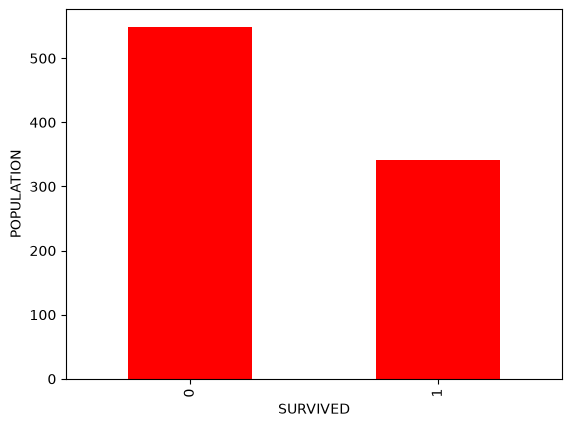

In [24]:
(titanic["Survived"].value_counts()).plot(kind="bar",color="red",xlabel="SURVIVED",ylabel="POPULATION")

In [25]:
import matplotlib.pyplot as plot

<Axes: title={'center': 'COUNTS'}, xlabel='Survived', ylabel='POPULATION'>

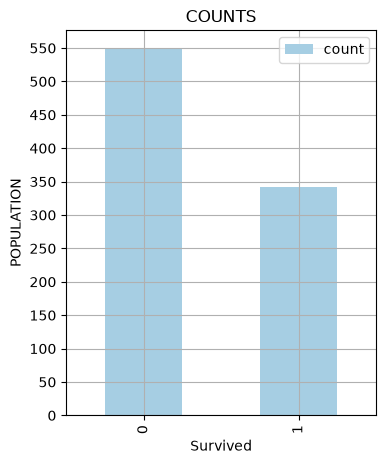

In [26]:
titanic["Survived"].value_counts().plot(kind="bar",title="COUNTS",ylabel="POPULATION",grid=True,legend=True,yticks=list(range(0,600,50)),figsize=(4,5),colormap="Paired")

<Axes: title={'center': 'MALE FEMALE SURVIVAL'}, xlabel='1= SURVIVED 0=DEAD', ylabel='POPULATION'>

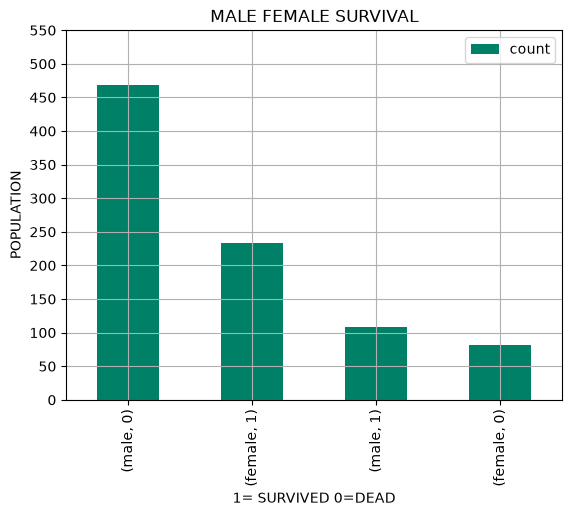

In [27]:
titanic[["Sex","Survived"]].value_counts().plot(kind="bar",title="MALE FEMALE SURVIVAL",colormap="summer",xlabel="1= SURVIVED 0=DEAD",ylabel="POPULATION",grid=True,yticks=list(range(0,600,50)),legend=True)

<Axes: title={'center': 'SURVIVAL GRAPH '}, xlabel='0=DEAD 1=SURVIVED', ylabel='POPULATION'>

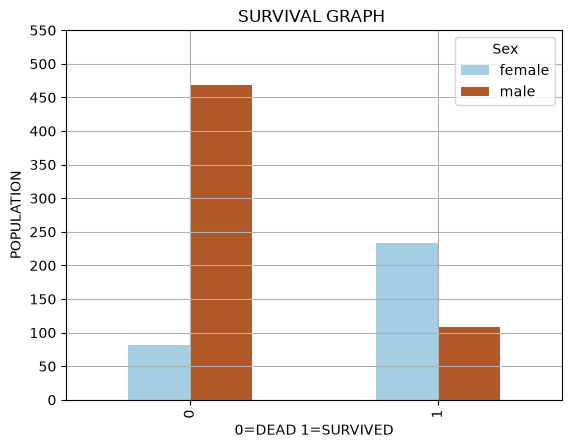

In [28]:
pd.crosstab(titanic.Survived,titanic.Sex).plot(kind="bar",yticks=list(range(0,600,50)),grid=True,colormap="Paired",title="SURVIVAL GRAPH ",ylabel="POPULATION",xlabel="0=DEAD 1=SURVIVED")

# PIE CHART 

<Axes: >

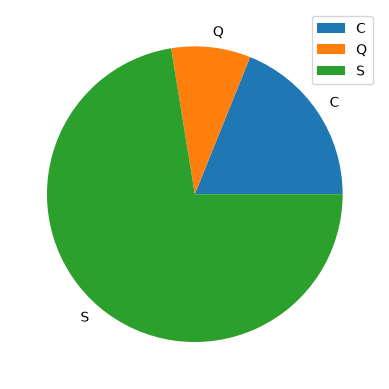

In [29]:
group=titanic.groupby("Embarked")
group.count().plot(kind="pie",y="Survived")

<Axes: ylabel='FEMALE AND MALE SURVIVAL RATE'>

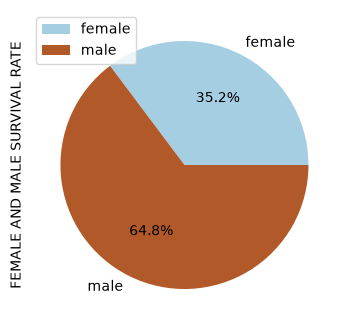

In [30]:
titanic.groupby("Sex").count().plot(kind="pie",y="Survived",grid=True,figsize=(4,5),ylabel="FEMALE AND MALE SURVIVAL RATE",colormap="Paired",autopct="%1.1f%%")

# HISTOGRAM

<Axes: title={'center': 'AGE HISTOGRAM'}, xlabel='AGE', ylabel='Frequency'>

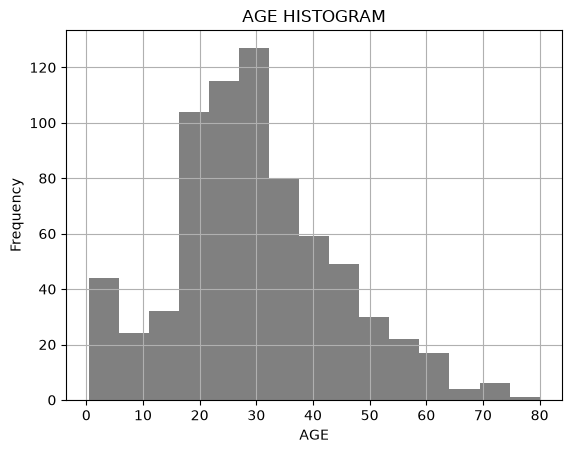

In [31]:
titanic.Age.plot(kind="hist",xlabel="AGE",title="AGE HISTOGRAM",grid=True,bins=15,color="grey")

<Axes: xlabel='FARE', ylabel='Frequency'>

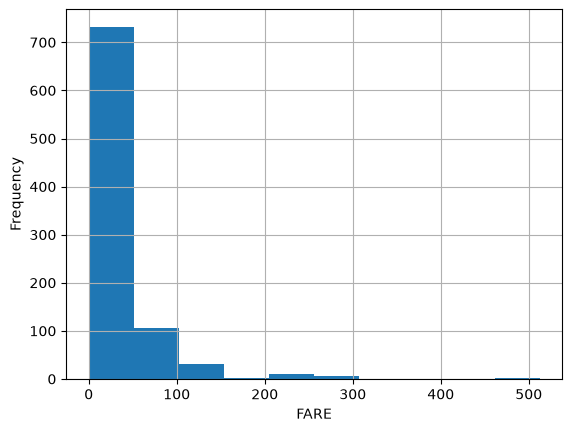

In [32]:
titanic.sample()
titanic.Fare.plot(kind="hist",xlabel="FARE",grid=True)

array([<Axes: title={'center': 'female'}, ylabel='Frequency'>,
       <Axes: title={'center': 'male'}, ylabel='Frequency'>], dtype=object)

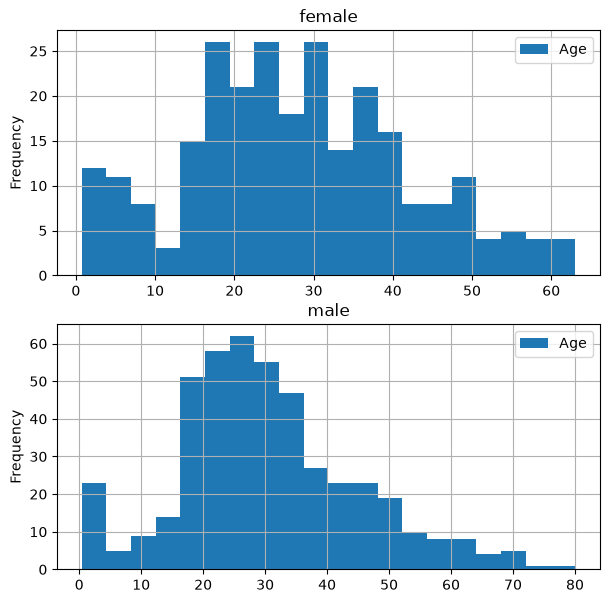

In [33]:
titanic[["Sex","Age"]].plot(kind="hist",by="Sex",grid=True,bins=20,colormap="Paired",figsize=(7,7))

# Line Graph 

<Axes: xlabel='FARE'>

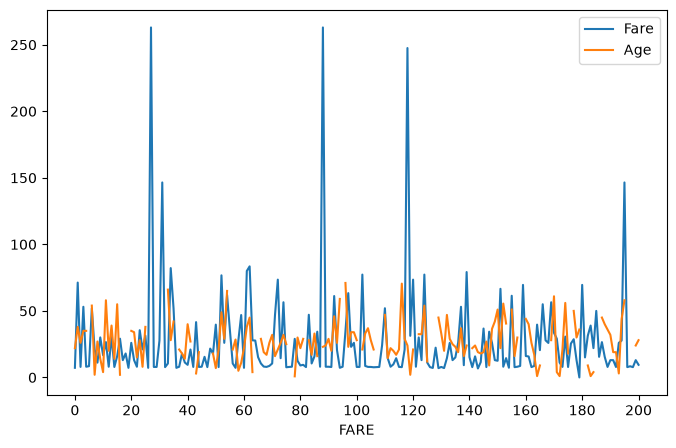

In [34]:
titanic[["Fare","Age"]].loc[:200].plot(kind="line",figsize=(8,5),xlabel="FARE",xticks=list(range(0,220,20)))

# SCATTERPLOT

<Axes: xlabel='Age', ylabel='Fare'>

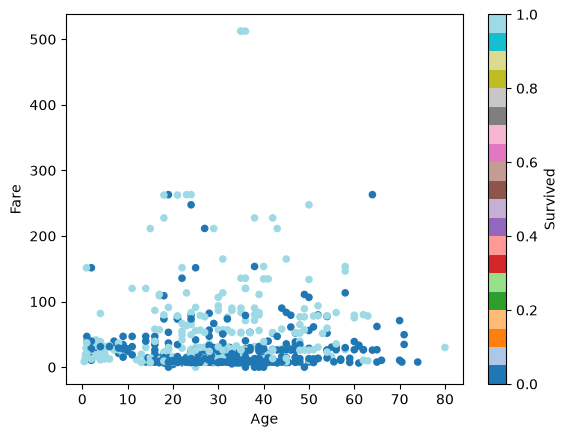

In [35]:
titanic.plot(kind="scatter",x="Age",y="Fare",c="Survived",colormap="tab20")

# BOX PLOT 

<Axes: title={'center': 'BOX PLOT OF AGE '}>

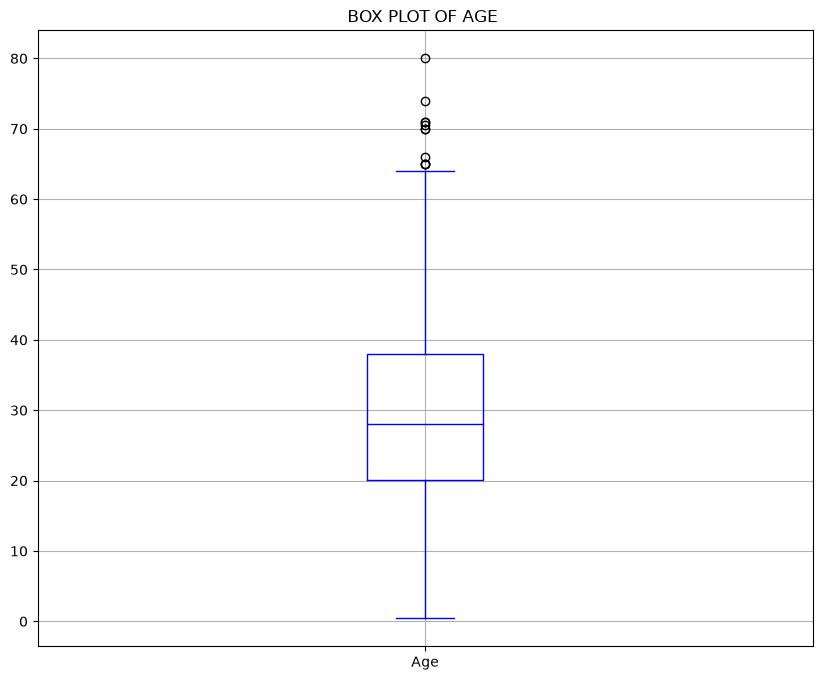

In [36]:
titanic.Age.plot(kind="box",title="BOX PLOT OF AGE ",figsize=(10,8),grid=True,color="blue")

Age    Axes(0.125,0.11;0.775x0.77)
dtype: object

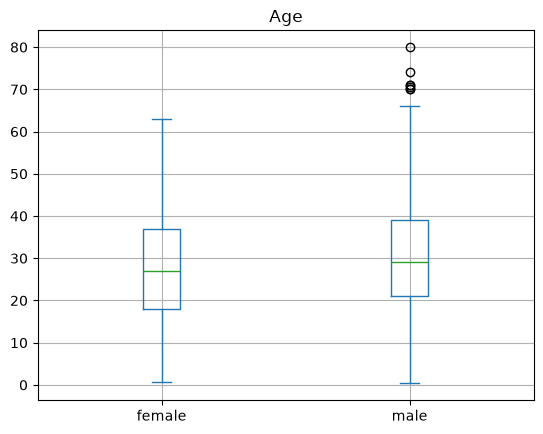

In [37]:
titanic.plot(kind="box",column="Age",by="Sex",grid=True)

array([<Axes: title={'center': 'C'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Q'}, ylabel='Frequency'>,
       <Axes: title={'center': 'S'}, ylabel='Frequency'>], dtype=object)

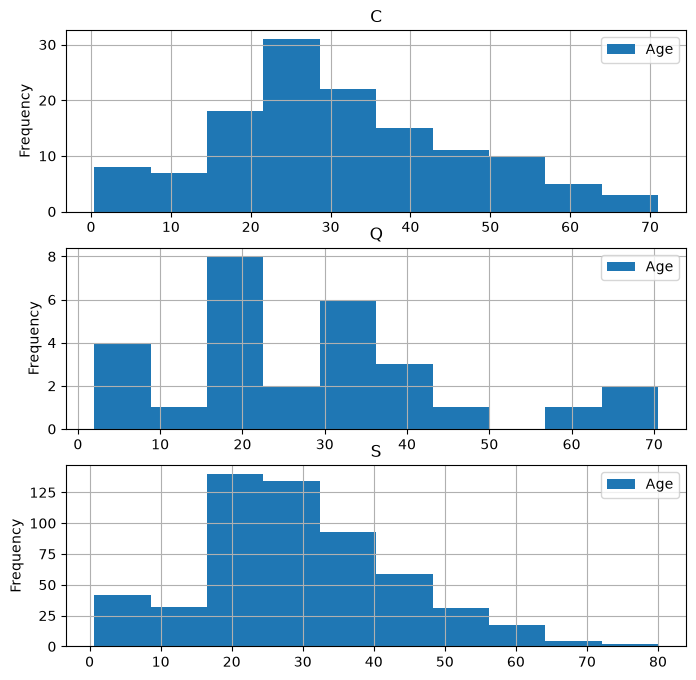

In [38]:
titanic.sample()
titanic.plot(kind="hist",column="Age",by="Embarked",grid=True,colormap="Paired",figsize=(8,8))

Age    Axes(0.125,0.11;0.775x0.77)
dtype: object

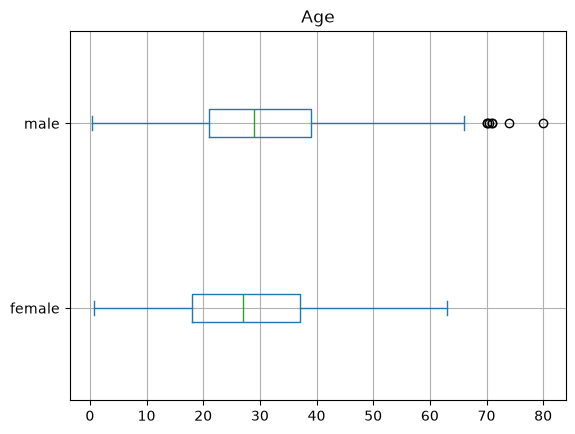

In [39]:
titanic.plot(kind="box",column="Age",by="Sex",grid=True,vert=False)

# HEAT MAP

In [40]:
corelation= titanic.corr(numeric_only=True )
import seaborn as sns

<Axes: >

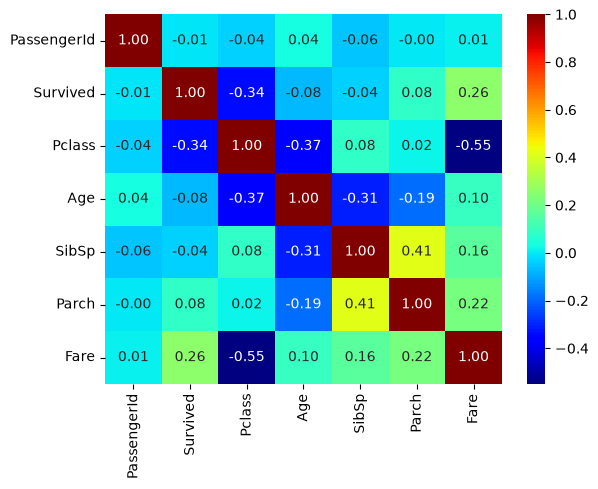

In [41]:
sns.heatmap(data=corelation,cmap="jet",annot=True,fmt=".2f")

# DENSITY PLOT OR KDE

<Axes: ylabel='Density'>

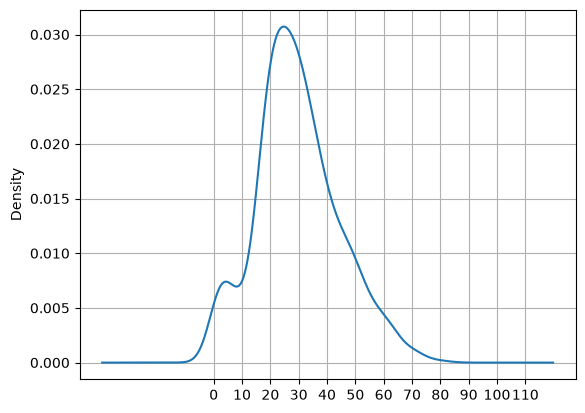

In [42]:
titanic.Age.plot(kind="kde",grid=True,xticks=list(range(0,120,10)))

# BUBBLE PLOT 

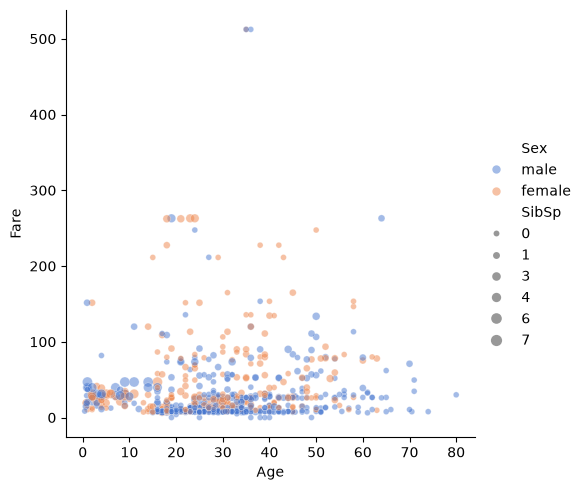

In [47]:
sns.relplot(data=titanic,x="Age",y="Fare",hue="Sex",size="SibSp",alpha=.5,palette="muted")

# VIOLIN PLOT

<Axes: xlabel='Age', ylabel='Sex'>

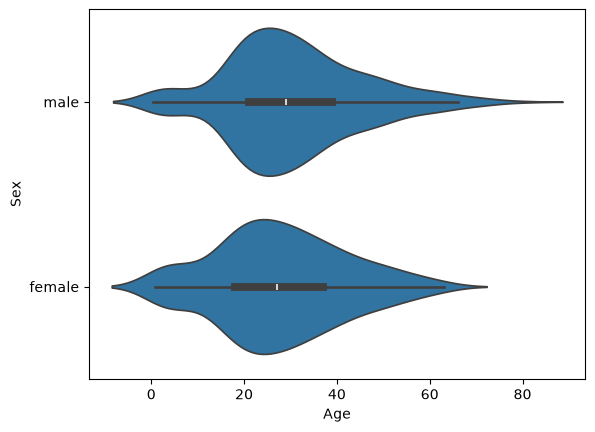

: 

In [ ]:
sns.violinplot(x=titanic["Age"],y=titanic["Sex"])